# El dilema de sesgo contra varianza

Uno de los problemas fundamentales en analítica predictiva es determinar la complejidad óptima del modelo. Se busca el mejor modelo que sea capaz de capturar la mayor variabilidad de los datos y que genere pronósticos precisos para información nueva. 

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

## Proceso generador de los datos
El proceso generador de datos es un proceso invisible que produce datos observables en el mundo real. Cuando se construye un modelo de regresión este es el proceso que se desea representar. A continuación se presenta un ejemplo numérico para ilustrar los conceptos.

Existe un proceso generador de datos f(x) que produce la salida y ante la entrada x. Este proceso es desconocido. Para efectos de este ejemplo, este será representado mediante la siguiente función:

In [8]:
#
# Función a aproximar
# (Proceso geneador de datos)
#
def f(x):
    return 2 * np.abs(np.sin(x * np.pi / 4 + 0.75)) / (1 + 0.1 * x)


#
# Datos reales.
# (No disponibles en la realidad)
# estos viene a ser como toda la población
x_real = np.linspace(0, 10, 100) # 100 datos igualmente espaciados entre 0 y 10
print(x_real.shape) # es simplemente un array normal
X_real = x_real[:, np.newaxis] # llevar a vector de 100 x 1. 
print(X_real.shape)
y_real = f(x_real) # evaluamos en la función. 
print(y_real.shape)

(100,)
(100, 1)
(100,)


## Muestra de datos
Cuando se construye un modelo de regresión que aproxime el comportamiento de $f(\cdot)$, los parámetros son calibrados mediante una muestra de datos, representada por las parejas $(x_i, d_i)$. La salida d_i no es exactamente $f(x_i)$ en la realidad, ya que el valor $y_i$ está contaminado con ruído.

In [9]:
#
# Muestra de datos.
# (Información disponible en la realidad)
#

# inicializar la semilla
rng = np.random.default_rng(12345)

x_sample = x_real.copy()

# mezcla aleatoria
rng.shuffle(x_sample)

# tomar los primeros 25
x_sample = x_sample[:25]

# ordenamos los datos
x_sample = np.sort(x_sample)

# calculamos el valor de la salida y obtener
# el Y de los 26 puntos
y_sample = f(x_sample)

# convertirmos en un vector, añadiendo las dimensiones en cada entrada. 
X_sample = x_sample[:, np.newaxis]

### Modelo de regresión
Por facilidad, se usará un polinomio de grado N para realizar la regresión:

$$y_p = g(x_p) = \phi_0 + \sum_{n=1}^N \phi_n x_p^n$$

donde el subíndice p representa cada uno de los puntos de la muestra de datos.

Para medir el grado de ajsute usamos el error cuadrático medio como función de pérdida. 

En aprendizaje automático, el proceso de aprendizaje consiste en estimar los valores de los parámetros $\phi_n$, para n=1, ...,N que minimizan un error o pérdida. Una selección común es el promedio de errores al cuadrado:

$$\text{MSE} = \frac{1}{P} \sum_{p=1}^P (d_p - y_p)^2 = \frac{1}{P} \sum_{p=1}^P [d_p - g(x_p)]^2$$

### Ajuste del modelo de los datos disponibles

El concepto de aprendizaje se refiere a que el modelo realmente capture el comportamiento del proceso generador de los datos (no visible). A continuación, se grafica el proceso subyacente y el comportamiento del polinomio para distintos grados.

En la práctica tampoco se conoce el grado del polinomio a usar, por tanto, lo mejor que se puede hacer es directamente probar diferentes grados de polinomios.

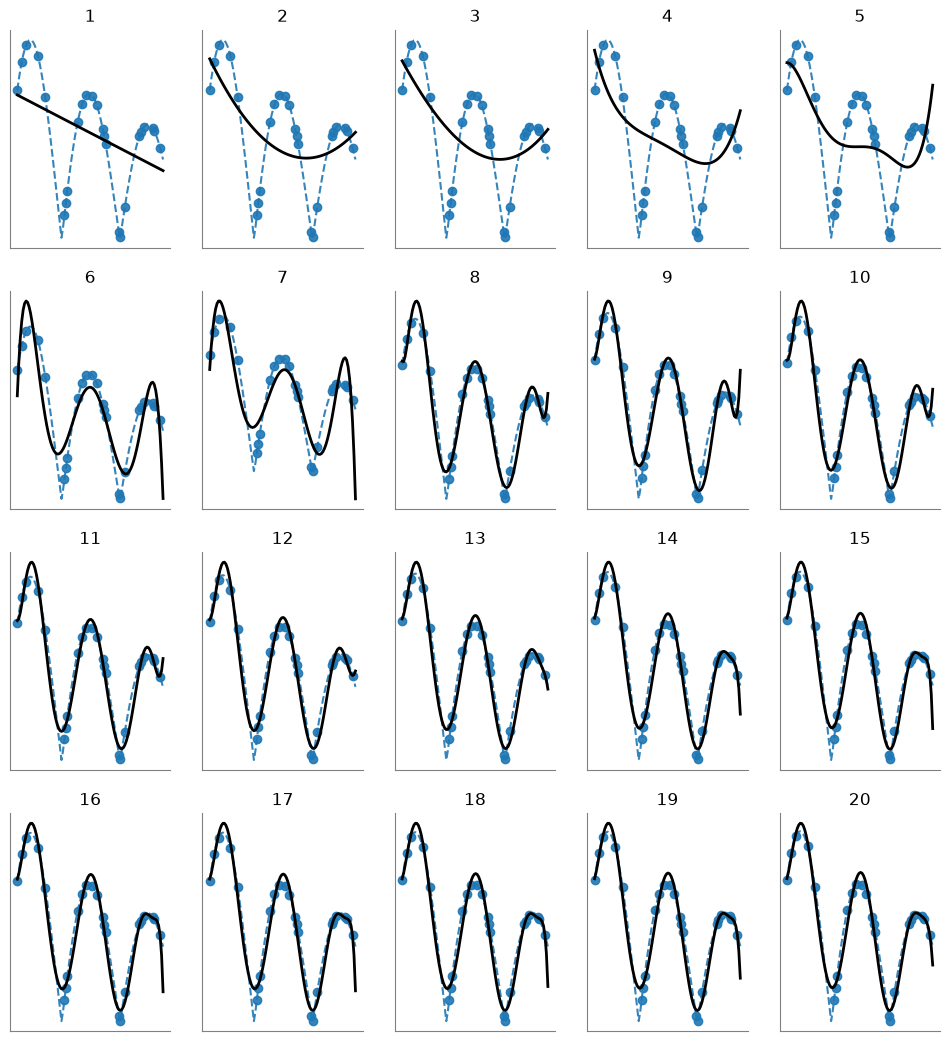

In [10]:
# tamaño de la figura
plt.figure(figsize=(12, 13))

# grados de polinomios a probar
# desde 1 hasta 20 incluido. 
degrees = list(range(1, 21)) # lista de valores del 1 al 20, para probar el gradod el polinomio

for i_degree, degree in enumerate(degrees):

    # divide toda la figura en una grilla
    # de 4 filas y 5 columnas y 
    # selecciona donde irá cada gráfico con 
    # i_degree + 1. 

    # plot.subplot(nrows, ncols, index)
    plt.subplot(4, 5, i_degree + 1)

    #
    # Datos
    #
    # datos reales
    plt.plot(x_real, y_real, "--", color="tab:blue", alpha=0.9)

    # muestra
    plt.plot(x_sample, y_sample, "o", color="tab:blue", alpha=0.9)

    #
    # Modelo
    #
    model = make_pipeline(
        # instancia del modelo de regresión 
        # lineal polinomial de grado "degree"
        # que entrega una matriz con los datos
        # elevados con el respectivo grado del polinomio. 
        PolynomialFeatures(degree, include_bias=False),

        # Escalamiento de los datos.
        # Para que queden en un formato 0 a 1
        # y no desvorden la matriz de los datos 
        MinMaxScaler(),

        # instancia del modelo 
        LinearRegression(),
    )

    # entrenamiento del modelo
    model.fit(X_sample, y_sample)

    # predicción del modelo
    y_predicted = model.predict(X_real)

    # datos reales en el eje X contra predichos
    # superpone el gráfico de los valores
    # predichos para ver como cada uno de los
    # modelos fue capaz de ajustarse y 
    # modelar los datos. 
    plt.plot(
        x_real,
        y_predicted,
        color="black",
        linewidth=2,
    )

    # asignar títulos
    plt.title(str(degree))

    # elimina marcas numéricas de los ejes para no tener
    # una saturación visual
    plt.xticks([], [])
    plt.yticks([], [])

    # gca: get current axes y spines modifica 
    # las líneas del recuadro del gráfico
    plt.gca().spines["left"].set_color("gray") # color de los ejes izquierdo
    plt.gca().spines["bottom"].set_color("gray") # colo de los ejes abajo
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)


plt.show()

En este caso, se puede suponer que el grado del polinomio es una medida de la complejidad del modelo; a mayor grado, mayor complejidad.

De acuedo con la gráfica anterior, se reconocen tres casos:

Subajuste: El modelo no reproduce adecuadamente el comportamiento de los datos usados para estimar sus parámetros, ni del comportamiento subyacente.

Sobreajuste: El modelo empieza a memorizar los datos de entrenamiento; es decir, muy bajo error de ajuste entre puntos, pero oscila locamente entre punto y punto para los puntos de la muestra de entrenamiento.

Ajuste óptimo: El modelo tiene un bajo error de ajuste y el comportamiento de la linea roja es muy similar al comportamiento de la línea negra.

En este caso un modelo de grado 10 o 11 pueden ser usados con confinza, pues son los que explican mayormente la variabilidad  de los datos (el anterior gráfico no está igual al video original), pues estos gráficos, son aquellos que permiten tener un control entre la vanrianza explicada y el ajuste, pues tiene una buena generalización para los datos nuevos, sin embargo, también hay que tener en cuenta la parsimonia y la interpratibilidad del modelo. 

![imagen real 1](../../imagenes/ej_1.png)
![imagen real 2](../../imagenes/ej_2.png)



la línea punteada azul son los datos reales, los puntos azules es la muestra de 25 seleccionada de manera aleatoria y la raya negra es el ajuste del modelo a estos datos. 

## Dilema sesgo-varianza
El término sesgo hace referencia a que tan bien se comporta el modelo para la muestra de datos disponible. En otras palabras, es el error promedio para diferentes muestras de entrenamiento.

El término varianza hace referencia a que tan bien se comporta el modelo para datos nuevos no disponibles hasta ahora (el modelo entra en productivo). En otras palabras, indica que tan sensitivos son los resultados obtenidos al variar el conjunto de entrenamiento.

**El dilema sesgo - varianza se refiere que a medida que el modelo aumenta su ajuste a los datos de entrenamiento (disminuye el sesgo), existe un punto a partir del cual aumenta la variabilidad de sus resultados para datos nuevos (aumenta la varianza).**

El dilema se presenta al querer disminuir simultáneamente el sesgo y la varianza.

En el gráfico anterior, a medida que aumenta la complejidad (el grado) del modelo, hay un mejor ajuste a los datos conocidos (muestra de entrenamiento), pero el modelo produce una salida muy volatil para puntos por fuera de la muestra (que aumenta con la complejidad del modelo). (ver imágenes reales)

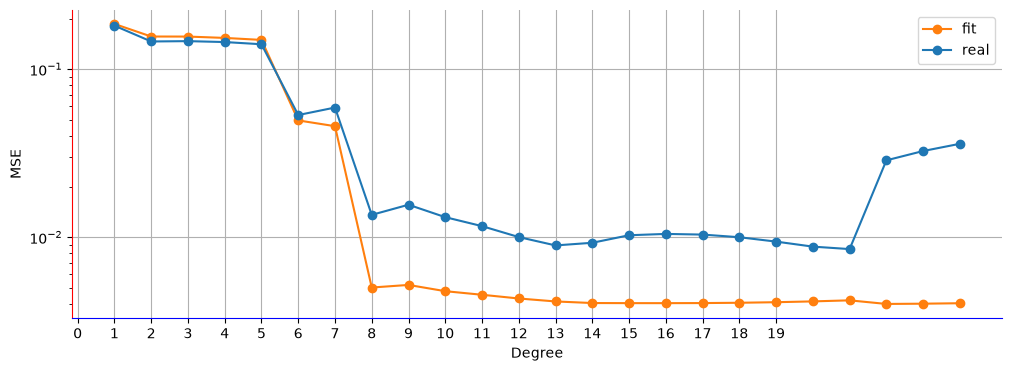

In [30]:
# cálculo de los errores
# El error del modelo respecto a la data conocida
# El error respecto al generador de los datos


from sklearn.metrics import mean_squared_error

# para cáculo del mse del entrenamiento
mse_fit = []

# para el cálculo de los datos reales
mse_real = []
degrees = list(range(1, 25))

for i_degree, degree in enumerate(degrees):

    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        MinMaxScaler(),
        LinearRegression(),
    )

    # entrenamiento del modelo con la muestra
    model.fit(X_sample, y_sample)

    # predicciones par la muestra
    y_sample_pred = model.predict(X_sample)

    # prediciones para los datos reales a aprtir de la muestra
    y_pred = model.predict(X_real)

    # guardar valores
    mse_fit.append(mean_squared_error(y_sample, y_sample_pred))
    mse_real.append(mean_squared_error(y_real.flatten(), y_pred))

# comparación de valores
plt.figure(figsize=(12, 4))

#               valores de eje X   , eje Y  
plt.plot(range(1, len(degrees) + 1), mse_fit, "o-", color="tab:orange", label="fit")
plt.plot(range(1, len(degrees) + 1), mse_real, "o-", color="tab:blue", label="real")

# que la escala del eje Y sea logaritmica
plt.yscale("log") # como son valores pequeños, muestra mejor la diferencia


plt.gca().spines["left"].set_color("red") # linea eje Y
plt.gca().spines["bottom"].set_color("blue") # línea de eje X
plt.gca().spines["top"].set_visible(False) # que no se vea la linea de arriba
plt.gca().spines["right"].set_visible(False) # que no se vea la linead de la derecha

plt.xticks(range(20)) # pone como todos los valroes del eje en específico. 
# para que nose salte ninguno

plt.xlabel("Degree")
plt.ylabel("MSE")
plt.legend()
plt.grid() # para mostrar cuadricula
plt.show()

Es notable que para los modelos de hasta grado 7 se tiene un ajuste muy malo tanto para la muestra como para el proceso generador, pero a medida de que aumenta el grado del polinomio empieza a reducirse este valor. Además, se espera que el valor para fit() sea igual o disminuya, en cambio para los valores reales será al contrario. 

Entre 8 y 13 se tieen el mayor banlance entre sesgo y ajuste, después de 13 empieza a empeorar para los datos reales y por ende implica sobre-ajuste. 

Sin embargo también recordemos el principio de parsimonia y buscar el modelo más simple puede ser lo adecuado. 
